# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2381 Ваньков Ярослав Сергеевич и Вакуленко Инна Юрьевна. Вариант №20.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

**Генеральная совокупность** — множество всех единиц наблюдения, для которых определяется изучаемый признак.  
**Выборка** — подмножество генеральной совокупности, отобранное по заданному правилу.

**Ранжированный ряд** — упорядочивание значений признака по возрастанию: x(1) <= x(2) <= ... <= x(n).

**Вариационный ряд** — перечень различных значений x_j с указанием их частот m_j. Относительная частота: m_tilde_j = m_j / n. Накопленные частоты: m^cum_j = сумма m_t по t<=j, m_tilde^cum_j = сумма m_tilde_t по t<=j.

**Интервальный ряд** — разбиение [x_min, x_max] на k частичных интервалов с подсчётом частот в каждом. Число интервалов k по формуле Стерджесса: k = ceil(1 + 3.322*log10(n)), ширина интервала h = (x_max - x_min) / k. Середина интервала: x_tilde_i = (x_i + x_(i+1)) / 2.

**Полигон частот** — ломаная по точкам (x_tilde_i, m_i) или (x_tilde_i, m_tilde_i). **Гистограмма** — столбчатая диаграмма по интервалам; высота столбца равна частоте или относительной частоте. **Эмпирическая функция распределения** F_n(x) — доля элементов выборки, не превосходящих x; ступенчатая, возрастает от 0 до 1.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Порядок выполнения работы

1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.  
2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.  
3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.  
4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.  
5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.  
6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

## Выполнение работы

### 1) Выбор языка

Для расчётов и построения графиков выбран **Python**: библиотеки pandas и numpy удобны для обработки табличных данных, matplotlib — для визуализации, все шаги выполняются в одном ноутбуке.

2–3) Источник данных и выборка

Генеральная совокупность — датасет Iris (UCI Machine Learning Repository):  
https://archive.ics.uci.edu/dataset/53/iris

Из него сформирована выборка в файле sample_120.csv: 120 наблюдений, два вещественных признака — sepal_length и sepal_width. Далее все ряды и графики строятся по признаку sepal_length.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv(r"./sample_120.csv")
df.head()

,sepal_length,sepal_width
0,5.2,3.4
1,4.6,3.4
2,5.9,3.2
3,6.0,2.2
4,4.9,2.4


In [2]:
df.info(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  120 non-null    float64
 1   sepal_width   120 non-null    float64
dtypes: float64(2)
memory usage: 2.0 KB


(None,
        sepal_length  sepal_width
 count    120.000000   120.000000
 mean       5.805833     3.054167
 std        0.831350     0.431705
 min        4.300000     2.000000
 25%        5.100000     2.800000
 50%        5.700000     3.000000
 75%        6.400000     3.300000
 max        7.700000     4.400000)

In [3]:
x = df["sepal_length"].to_numpy()
n = len(x)
x_sorted = np.sort(x)
x_sorted[:20], x_sorted[-10:], n

(array([4.3, 4.4, 4.4, 4.5, 4.6, 4.6, 4.6, 4.7, 4.7, 4.8, 4.8, 4.8, 4.8,
        4.9, 4.9, 4.9, 4.9, 4.9, 4.9, 5. ]),
 array([7. , 7.1, 7.2, 7.2, 7.3, 7.6, 7.7, 7.7, 7.7, 7.7]),
 120)

In [4]:
vals, counts = np.unique(x_sorted, return_counts=True)

var_df = pd.DataFrame({
    "x": vals,
    "m": counts
})
var_df["m_tilde"] = var_df["m"] / n
var_df["m_cum"] = var_df["m"].cumsum()
var_df["m_tilde_cum"] = var_df["m_tilde"].cumsum()

var_df.head(10)

,x,m,m_tilde,m_cum,m_tilde_cum
0,4.3,1,0.008333,1,0.008333
1,4.4,2,0.016667,3,0.025000
2,4.5,1,0.008333,4,0.033333
3,4.6,3,0.025000,7,0.058333
4,4.7,2,0.016667,9,0.075000
5,4.8,4,0.033333,13,0.108333
6,4.9,6,0.050000,19,0.158333
7,5.0,9,0.075000,28,0.233333
8,5.1,7,0.058333,35,0.291667
9,5.2,3,0.025000,38,0.316667


4) Интервальный ряд (Таблица 1)

In [5]:
k = math.ceil(1 + 3.322 * math.log10(n))
xmin, xmax = float(x.min()), float(x.max())
h = (xmax - xmin) / k
bins = np.array([xmin + i*h for i in range(k)] + [xmax])
bins[-1] = xmax + 1e-12

cats = pd.cut(x, bins=bins, right=False, include_lowest=True)
m = cats.value_counts().sort_index().to_numpy()

mid = (bins[:-1] + bins[1:]) / 2

int_df = pd.DataFrame({
    "i": np.arange(1, k+1),
    "[x_i; x_{i+1})": [f"[{bins[i]:.4f}; {bins[i+1]:.4f})" for i in range(k)],
    "x_tilde_i": np.round(mid, 6),
    "m_i": m,
})
int_df["m_tilde_i"] = int_df["m_i"] / n
int_df["m_i_cum"] = int_df["m_i"].cumsum()
int_df["m_tilde_i_cum"] = int_df["m_tilde_i"].cumsum()

int_df

,i,[x_i; x_{i+1}),x_tilde_i,m_i,m_tilde_i,m_i_cum,m_tilde_i_cum
0,1,[4.3000; 4.7250),4.5125,9,0.075000,9,0.075000
1,2,[4.7250; 5.1500),4.9375,26,0.216667,35,0.291667
2,3,[5.1500; 5.5750),5.3625,16,0.133333,51,0.425000
3,4,[5.5750; 6.0000),5.7875,20,0.166667,71,0.591667
4,5,[6.0000; 6.4250),6.2125,20,0.166667,91,0.758333
5,6,[6.4250; 6.8500),6.6375,16,0.133333,107,0.891667
6,7,[6.8500; 7.2750),7.0625,7,0.058333,114,0.950000
7,8,[7.2750; 7.7000),7.4875,6,0.050000,120,1.000000


In [6]:
df_int_pretty = int_df.rename(columns={
    "[x_i; x_{i+1})": "[x_i, x_{i+1})",
    "x_tilde_i": "x_tilde_i",
    "m_tilde_i": "m_tilde_i",
    "m_i_cum": "m_i^cum",
    "m_tilde_i_cum": "m_tilde_i^cum"
}).copy()

row_sum = pd.DataFrame([{
    "i": "Sum",
    "[x_i, x_{i+1})": "",
    "x_tilde_i": "",
    "m_i": int_df["m_i"].sum(),
    "m_tilde_i": int_df["m_tilde_i"].sum(),
    "m_i^cum": "-",
    "m_tilde_i^cum": "-"
}])

result_int_df = pd.concat([df_int_pretty, row_sum], ignore_index=True)
result_int_df

,i,"[x_i, x_{i+1})",x_tilde_i,m_i,m_tilde_i,m_i^cum,m_tilde_i^cum
0,1,[4.3000; 4.7250),4.5125,9,0.075000,9,0.075
1,2,[4.7250; 5.1500),4.9375,26,0.216667,35,0.291667
2,3,[5.1500; 5.5750),5.3625,16,0.133333,51,0.425
3,4,[5.5750; 6.0000),5.7875,20,0.166667,71,0.591667
4,5,[6.0000; 6.4250),6.2125,20,0.166667,91,0.758333
5,6,[6.4250; 6.8500),6.6375,16,0.133333,107,0.891667
6,7,[6.8500; 7.2750),7.0625,7,0.058333,114,0.95
7,8,[7.2750; 7.7000),7.4875,6,0.050000,120,1.0
8,Sum,,,120,1.000000,-,-


По таблице и графикам видно, что значения sepal_length в выборке из Iris сосредоточены в средней части диапазона. Ранжированный ряд задаёт порядок наблюдений, вариационный — повторяемость различных значений, интервальный — группировку по отрезкам. Накопленные частоты монотонно растут от 0 до 1; наибольшие столбцы гистограммы приходятся на центральные интервалы.

In [7]:
k, h, xmin, xmax

(8, 0.42500000000000004, 4.3, 7.7)

По таблице: интервал с наибольшей частотой m_i — самый заполненный; размах выборки задаётся xmin и xmax (см. вывод выше).

5) Полигон, гистограмма и ЭФР (абсолютные частоты)

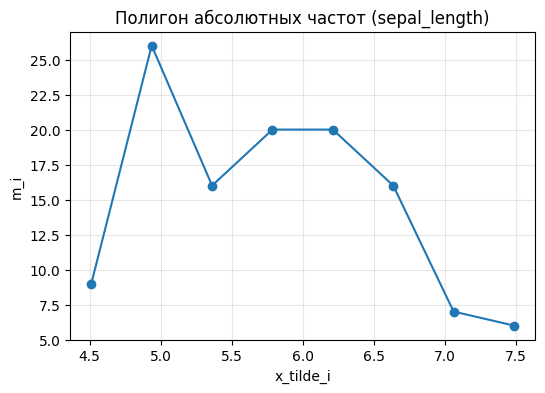

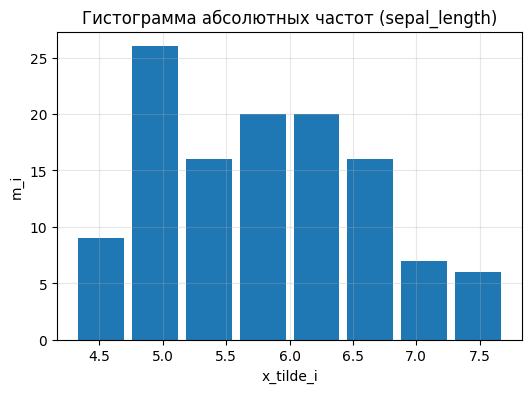

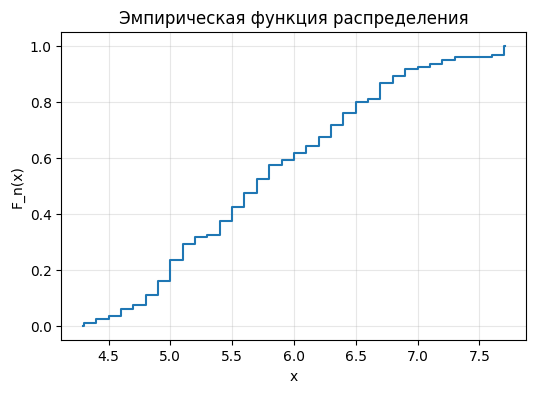

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(mid, int_df["m_i"], "o-")
plt.xlabel("x_tilde_i")
plt.ylabel("m_i")
plt.title("Полигон абсолютных частот (sepal_length)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(mid, int_df["m_i"], width=h*0.85, align="center")
plt.xlabel("x_tilde_i")
plt.ylabel("m_i")
plt.title("Гистограмма абсолютных частот (sepal_length)")
plt.grid(True, alpha=0.3)
plt.show()

sorted_x = np.sort(x)
Fn = np.arange(1, n + 1) / n
plt.figure(figsize=(6, 4))
plt.step(np.concatenate([[sorted_x[0]-0.01], sorted_x, [sorted_x[-1]+0.01]]),
         np.concatenate([[0], Fn, [1]]), where="post")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Эмпирическая функция распределения")
plt.grid(True, alpha=0.3)
plt.show()

6) Полигон, гистограмма и ЭФР (относительные частоты)

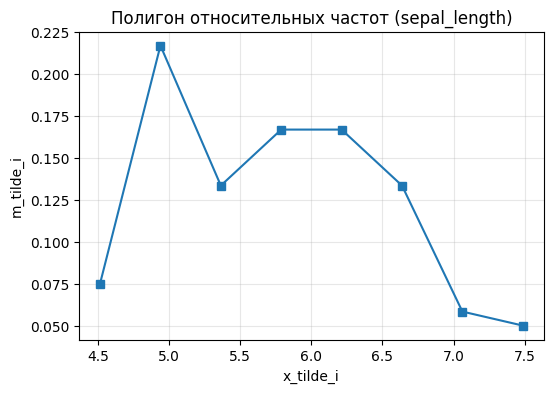

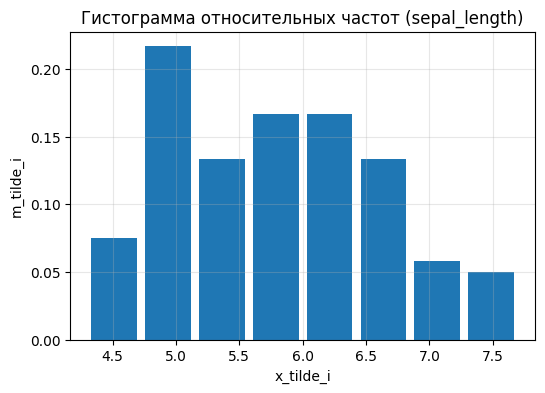

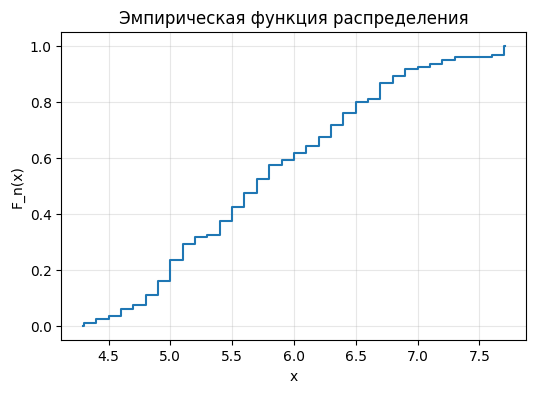

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(mid, int_df["m_tilde_i"], "s-")
plt.xlabel("x_tilde_i")
plt.ylabel("m_tilde_i")
plt.title("Полигон относительных частот (sepal_length)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(mid, int_df["m_tilde_i"], width=h*0.85, align="center")
plt.xlabel("x_tilde_i")
plt.ylabel("m_tilde_i")
plt.title("Гистограмма относительных частот (sepal_length)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.step(np.concatenate([[sorted_x[0]-0.01], sorted_x, [sorted_x[-1]+0.01]]),
         np.concatenate([[0], Fn, [1]]), where="post")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Эмпирическая функция распределения")
plt.grid(True, alpha=0.3)
plt.show()

**Сравнение абсолютных и относительных частот.** Полигоны и гистограммы по m_i и по m_tilde_i совпадают по форме; различается только масштаб по вертикали (число наблюдений против доли). Эмпирическая функция распределения F_n(x) строится один раз и не зависит от того, считаем ли мы абсолютные или относительные частоты.

## Выводы

1. Выборка объёма 120 сформирована из датасета Iris; рассмотрены признаки sepal_length и sepal_width, ряды и графики построены по sepal_length.  
2. По интервальному ряду получены полигон частот, гистограмма и эмпирическая функция распределения как для абсолютных, так и для относительных частот.  
3. Визуально полигоны и гистограммы для m_i и m_tilde_i совпадают по форме; различие — в шкале ординат (количество против доли). ЭФР при этом одна и та же.